# Regeneration study of NTX injured muscle 

>De Micheli AJ, Laurilliard EJ, Heinke CL, Ravichandran H, Fraczek P, Soueid-Baumgarten S, De Vlaminck I, Elemento O, Cosgrove BD. Single-Cell Analysis of the Muscle Stem Cell Hierarchy Identifies Heterotypic Communication Signals Involved in Skeletal Muscle Regeneration. Cell Rep. 2020 Mar 10;30(10):3583-3595.e5. doi: 10.1016/j.celrep.2020.02.067. PMID: 32160558; PMCID: PMC7091476.

https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE143437

## Setup

In [1]:
import scvelo as scv
import scanpy as sc
import numpy as np
import anndata as ad
import pandas as pd

scv.settings.verbosity = 3  # show errors(0), warnings(1), info(2), hints(3)
scv.settings.presenter_view = True  # set max width size for presenter view
scv.settings.set_figure_params('scvelo')  # for beautified visualization

## Load data

In [2]:
samples = {
    'D0_A':"SRR10870296", 'D0_B':"SRR10870297", 'D0_Cv3':"SRR10870298",
    'D2_C':"SRR10870299", 'D2_D':"SRR10870300", 'D5_A':"SRR10870301",
    'D5_B':"SRR10870302", 'D5_C':"SRR10870303",
    'D7_C':"SRR10870304", 'D7_D':"SRR10870305"
}

In [3]:
fmt = "/home/kazumitsu.maehara/work/scdataset/SRP241205/kb/%s/counts_filtered/adata.h5ad"
adata = ad.concat([ad.read_h5ad(fmt % acc) for acc in samples.values()],join='outer',merge='same',index_unique='-',label='sampleID',keys=samples.keys())
adata.var.index = adata.var.index.str.split('.').str[0] # remove version num.
adata.obs.index = [key[1] + "_" + key[0] for key in adata.obs.index.str.split('-')]
adata

AnnData object with n_obs × n_vars = 83390 × 56941
    obs: 'sampleID'
    layers: 'mature', 'nascent'

## Filtering & annotation

In [4]:
# obs
dfobs = pd.read_table("/home/kazumitsu.maehara/work/scdataset/SRP241205/metadata/GSE143437_DeMicheli_MuSCatlas_metadata.txt.gz", index_col=0)
cells = dfobs.index.intersection(adata.obs.index)
adata = adata[cells,:]
adata.obs = dfobs.loc[cells]
adata

# var
annot = sc.queries.biomart_annotations(
    "mmusculus",
    ["ensembl_gene_id", "external_gene_name", "gene_biotype"],
).set_index("ensembl_gene_id")

genes = annot.index.intersection(adata.var.index)
adata = adata[:,genes]
adata.var = annot.loc[genes]
adata = adata[:,adata.var.gene_biotype == "protein_coding"]
adata.var.index = adata.var.external_gene_name.astype('str')
adata.var.rename(columns={'external_gene_name':'gene_name'}, inplace=True)
adata.var_names_make_unique()
adata.var.index.name = 'index'
adata

AnnData object with n_obs × n_vars = 34438 × 21717
    obs: 'sampleID', 'nUMI', 'nGene', 'percent_mito', 'injury', 'cell_annotation'
    var: 'gene_name', 'gene_biotype'
    layers: 'mature', 'nascent'

## Check whether X is spliced count

In [5]:
adata.layers['unspliced'] = adata.layers['nascent']
adata.layers['spliced'] = adata.layers['mature']
del adata.layers['nascent']
del adata.layers['mature']

In [6]:
adata.X.sum(), adata.layers["spliced"].sum(), adata.layers["unspliced"].sum()

(np.float64(274154399.0), np.float64(233286778.0), np.float64(40867621.0))

## RNA velocity

calculating cell cycle phase
-->     'S_score' and 'G2M_score', scores of cell cycle phases (adata.obs)
Filtered out 6380 genes that are detected 20 counts (spliced).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
computing moments based on connectivities
    finished (0:00:52) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities


/usr/local/packages/mambaforge/lib/python3.11/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:00:30) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 32/48 cores)


  0%|          | 0/34438 [00:00<?, ?cells/s]

    finished (0:00:31) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


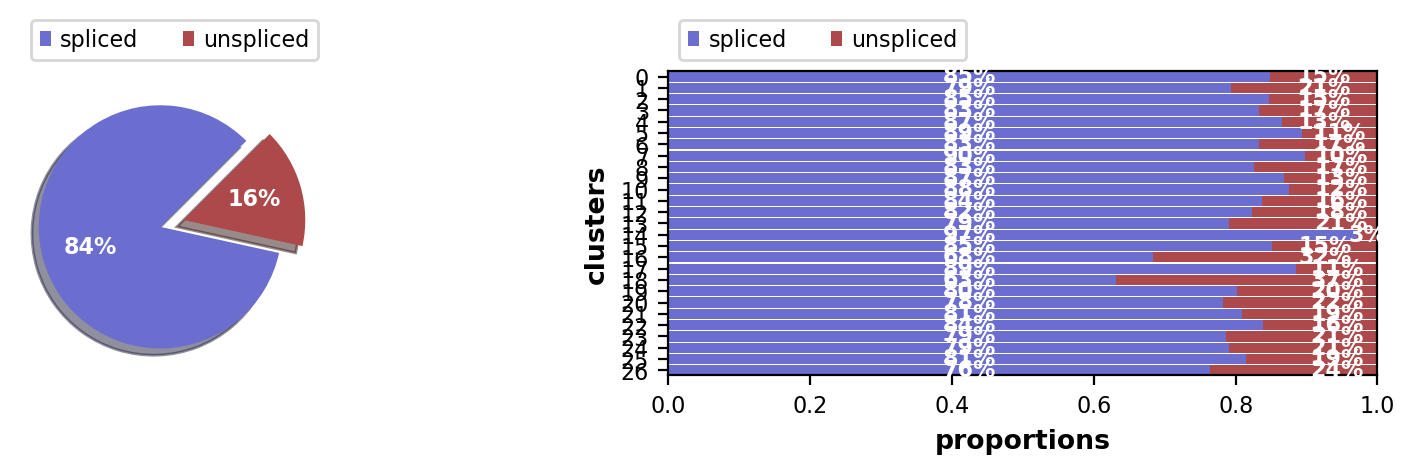

computing velocity embedding
    finished (0:00:08) --> added
    'velocity_pca', embedded velocity vectors (adata.obsm)


/usr/local/packages/mambaforge/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/usr/local/packages/mambaforge/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/usr/local/packages/mambaforge/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/usr/local/packages/mambaforge/lib/python3.11/site-packages/scvelo/plo

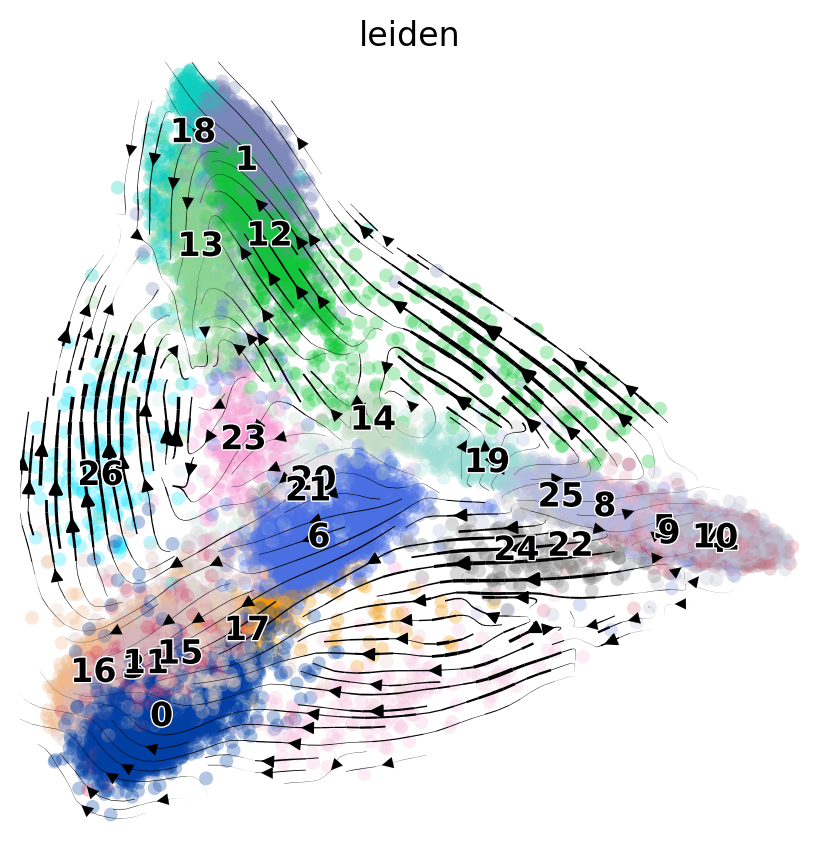

computing velocity embedding
    finished (0:00:06) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/usr/local/packages/mambaforge/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/usr/local/packages/mambaforge/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/usr/local/packages/mambaforge/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/usr/local/packages/mambaforge/lib/python3.11/site-packages/scvelo/plo

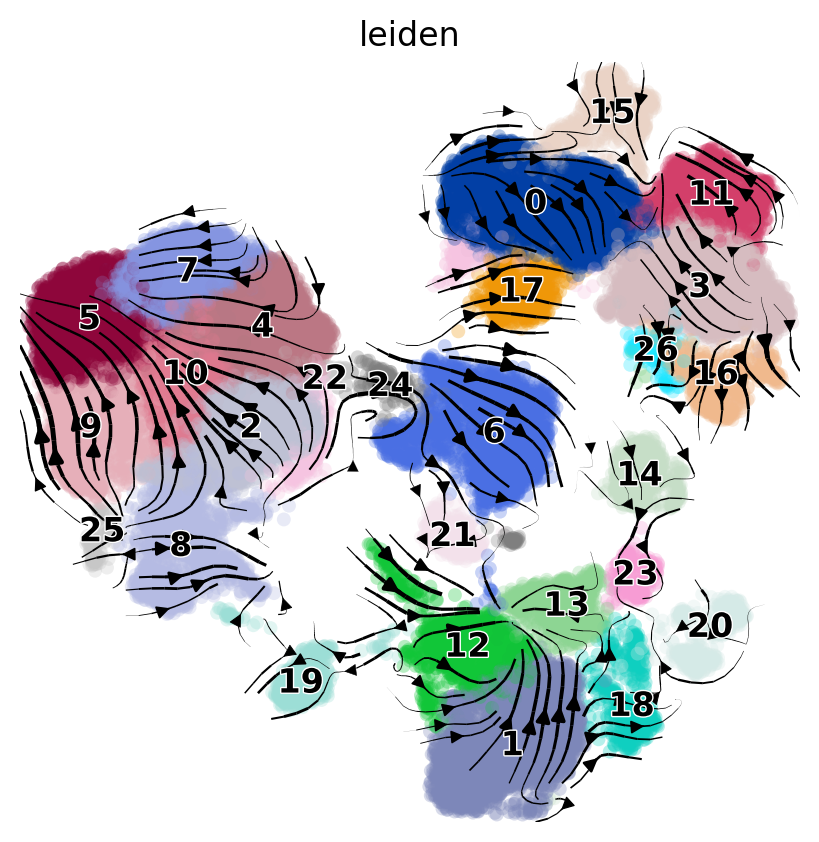

In [7]:
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
#sc.pp.filter_cells(adata, min_genes=500)
scv.tl.score_genes_cell_cycle(adata)
#sc.pp.filter_genes(adata, min_cells=20)
scv.pp.filter_genes(adata, min_counts=20)
scv.pp.normalize_per_cell(adata)
#sc.pp.normalize_total(adata, target_sum=1e4)
adata.raw = adata
sc.pp.log1p(adata)
scv.pp.filter_genes_dispersion(adata, n_top_genes=2000, subset=False) # 3000 in Qiu
#scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=30)
scv.pp.moments(adata, n_pcs=None, n_neighbors=None)
scv.tl.velocity(adata,mode="stochastic")
#scv.tl.velocity_embedding(adata, basis='pca',direct_pca_projection=True) # test
scv.tl.velocity_graph(adata,n_jobs=32)
#scv.tl.umap(adata,min_dist=0.8,maxiter=500,random_state=1231) # for scvelo < 0.3.3
sc.tl.umap(adata,min_dist=0.8,maxiter=500,random_state=1231)
sc.tl.leiden(adata)
adata.obs["clusters"] = adata.obs["leiden"]
scv.pl.proportions(adata,groupby='clusters')
#scv.pl.scatter(adata, color_gradients=['S_score', 'G2M_score'], smooth=True, perc=[5, 95],figsize=(5,5))
scv.pl.velocity_embedding_stream(adata, basis='pca',  color='leiden',size=100,figsize=(5,5))
scv.pl.velocity_embedding_stream(adata, basis='umap', color='leiden',size=100,figsize=(5,5))

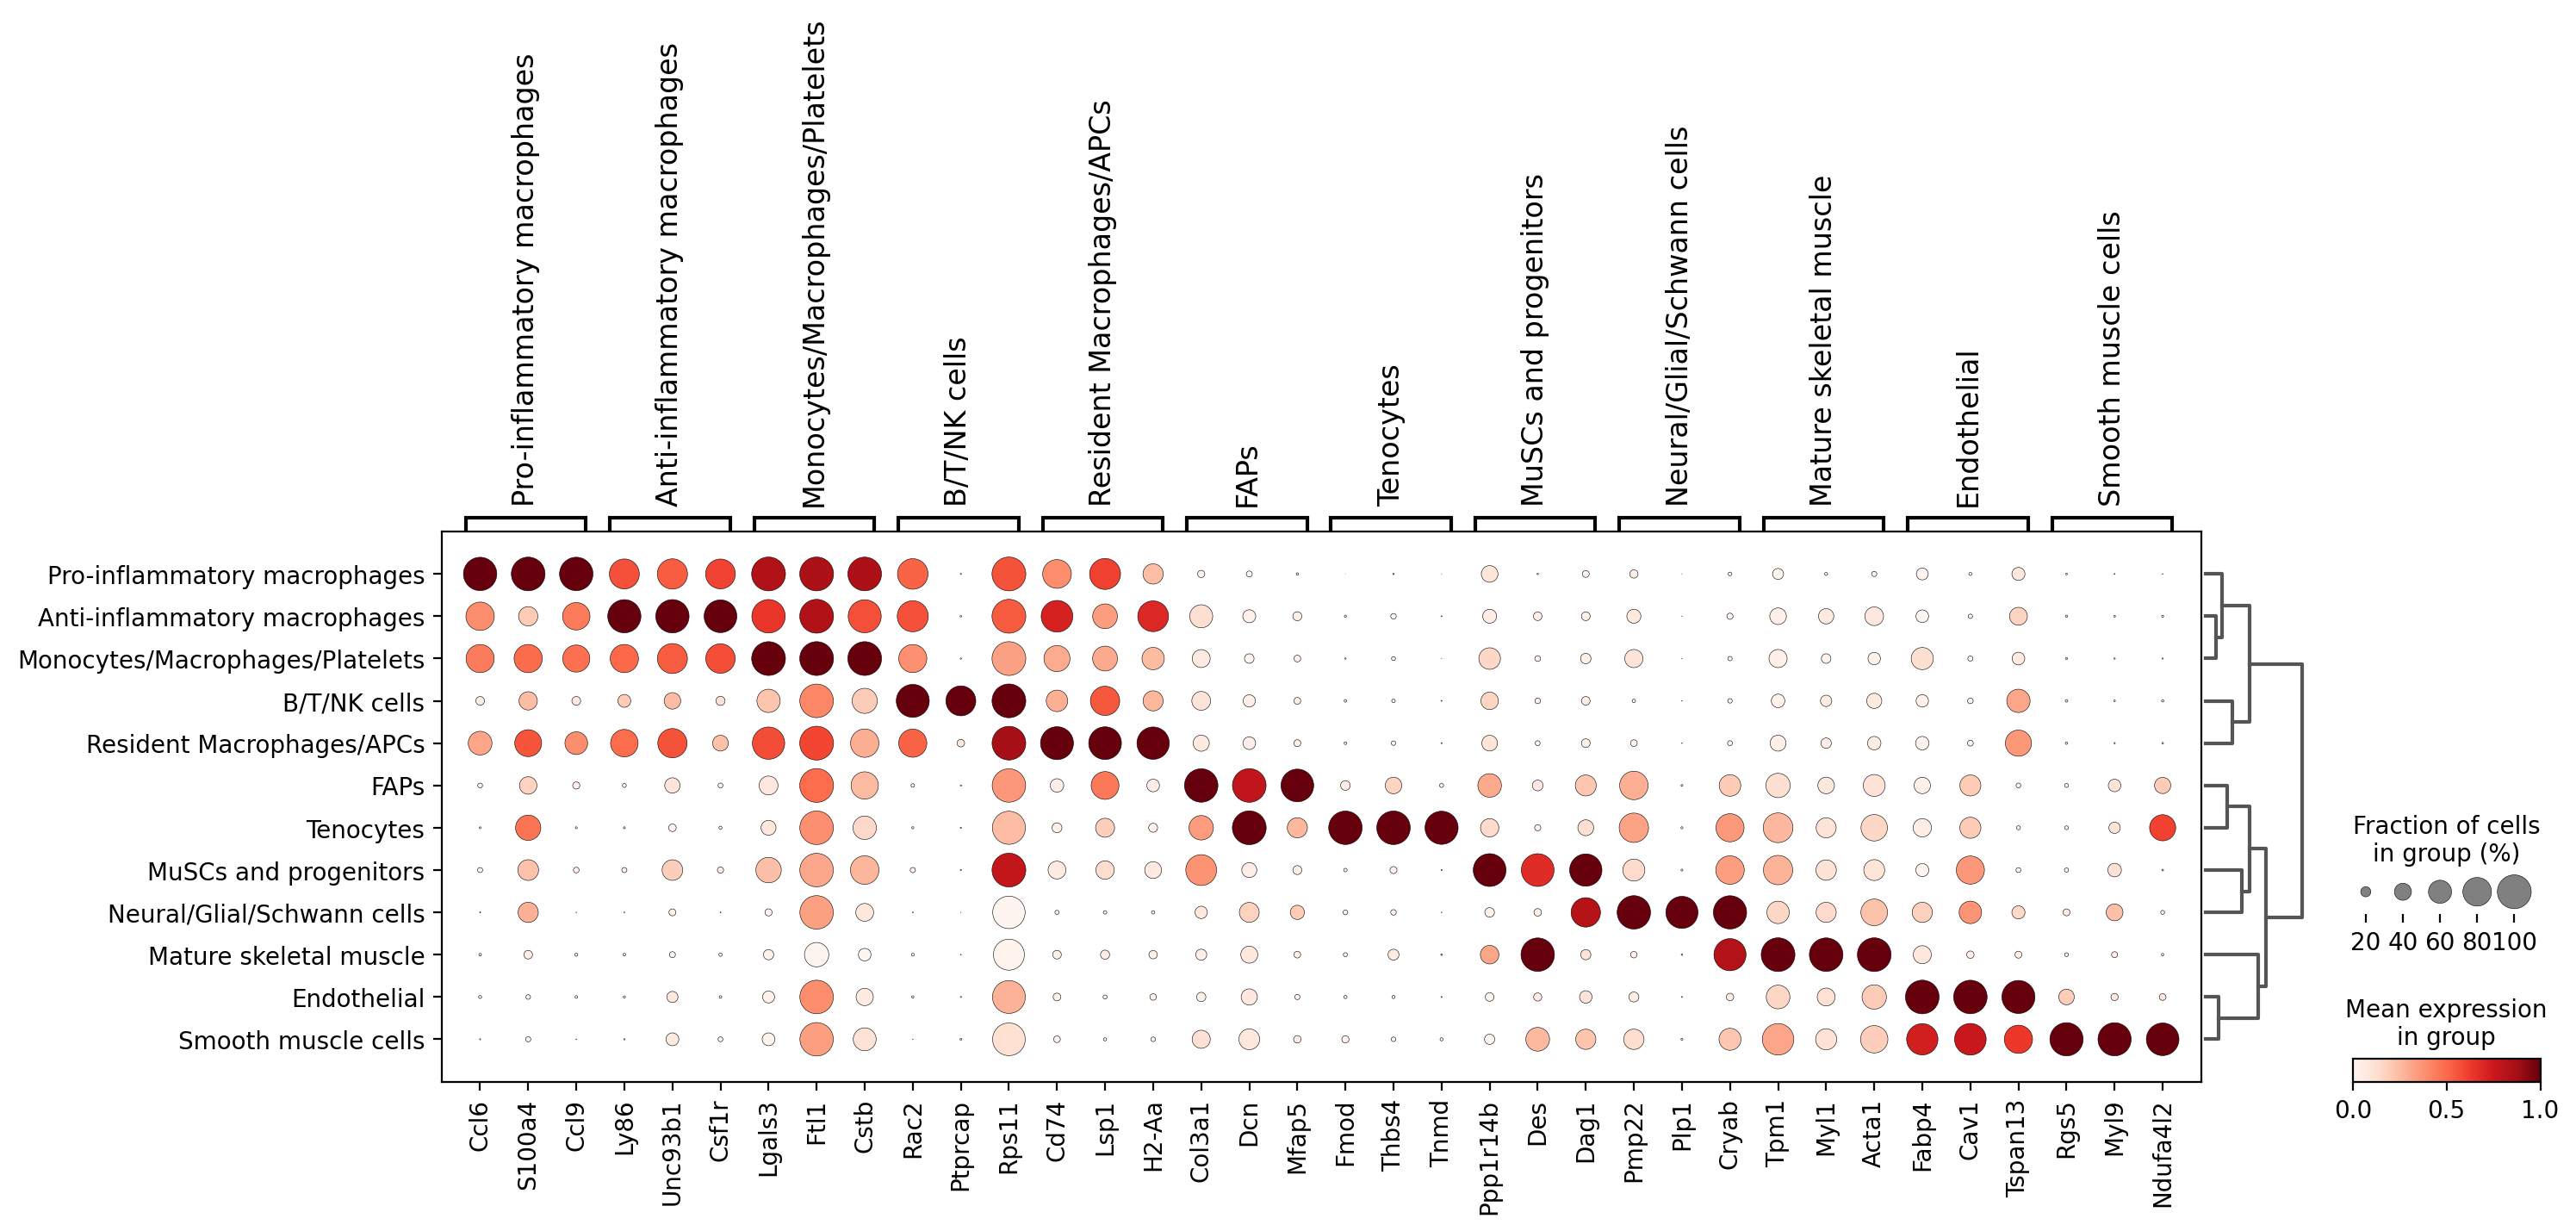

In [8]:
grp = "cell_annotation"
#grp = "leiden"
sc.tl.dendrogram(adata, groupby=grp)
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata, groupby=grp, method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    adata, groupby=grp, standard_scale="var", n_genes=3
)

In [9]:
adata.write("../data/scNTX.h5ad")